Experiment - 3 (Singular Value Decomposition)

---

Name : Shruti Hore

PRN : 24070126172

---

About dataset :
- The Digits dataset contains images of handwritten digits (0–9).

- Each image is 8×8 pixels, resulting in 64 numerical features per sample.

- It has 1,797 samples with 10 target classes (digits 0–9).

## Load Image Dataset

In [12]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [5]:
digits = load_digits()

# Features
x = digits.data
y = digits.target

print('Data shape :', x.shape)
print('Image Shape :', digits.images[0].shape)

Data shape : (1797, 64)
Image Shape : (8, 8)


## Visualize sample images

In [17]:
digits.images[6]

array([[ 0.,  0.,  0., 12., 13.,  0.,  0.,  0.],
       [ 0.,  0.,  5., 16.,  8.,  0.,  0.,  0.],
       [ 0.,  0., 13., 16.,  3.,  0.,  0.,  0.],
       [ 0.,  0., 14., 13.,  0.,  0.,  0.,  0.],
       [ 0.,  0., 15., 12.,  7.,  2.,  0.,  0.],
       [ 0.,  0., 13., 16., 13., 16.,  3.,  0.],
       [ 0.,  0.,  7., 16., 11., 15.,  8.,  0.],
       [ 0.,  0.,  1.,  9., 15., 11.,  3.,  0.]])

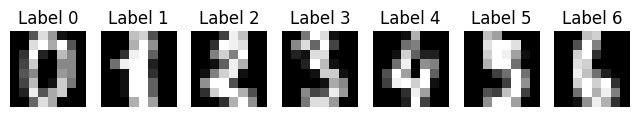

In [16]:
plt.figure(figsize=(8,3))
for i in range(7):
    plt.subplot(1, 7, i+1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f'Label {y[i]}')
    plt.axis('off')
plt.show()

## Standardize the Data

In [18]:
SS = StandardScaler()
x_scaled = SS.fit_transform(x)

## Full SVD Decomposition

In [19]:
U, S, Vt = np.linalg.svd(x_scaled, 
                         full_matrices=False)

print('Left Singular Vector (U) Shape :', U.shape)
print('Diagonal Matrix (Σ) Shape :', S.shape)
print('Right Singular Vector (Vᵀ) Shape :', Vt.shape)

Left Singular Vector (U) Shape : (1797, 64)
Diagonal Matrix (Σ) Shape : (64,)
Right Singular Vector (Vᵀ) Shape : (64, 64)


<function matplotlib.pyplot.show(close=None, block=None)>

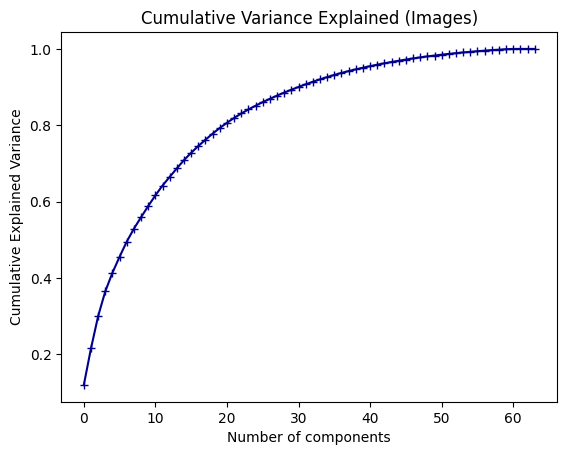

In [22]:
explained_var = (S**2) / np.sum(S**2)

plt.figure()
plt.plot(np.cumsum(explained_var), marker='+', color='darkblue')
plt.xlabel("Number of components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Explained (Images)")
plt.show

## Dimensionality Reduction

In [23]:
k = 20
Uk = U[:, :k]
Sk = np.diag(S[:k])
Vtk = Vt[:k, :]

x_redu = Uk @ Sk
print('Reduced data shape :', x_redu.shape)

Reduced data shape : (1797, 20)


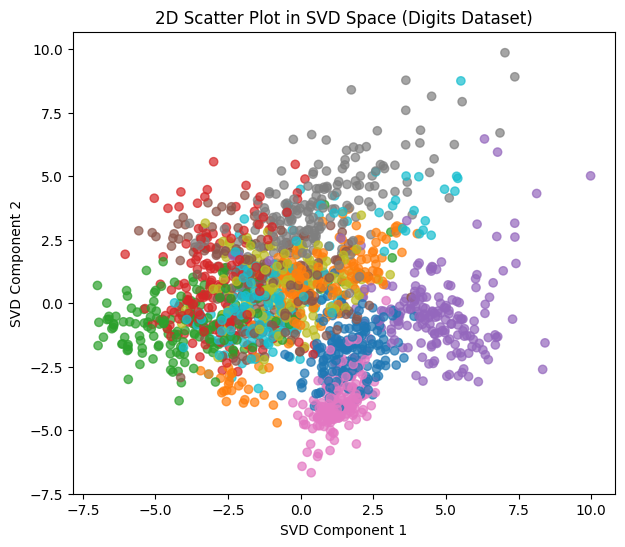

In [24]:
# 2D scatter plot for first 2 SVD components
k_sc = 2
Uk_sc = U[:, :k_sc]
Sk_sc = np.diag(S[:k_sc])

x_2d = Uk_sc @ Sk_sc

plt.figure(figsize=(7, 6))
scatter = plt.scatter(x_2d[:,0], x_2d[:,1],
                      c=y, cmap='tab10', alpha=0.7)
plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')
plt.title('2D Scatter Plot in SVD Space (Digits Dataset)')
plt.show()

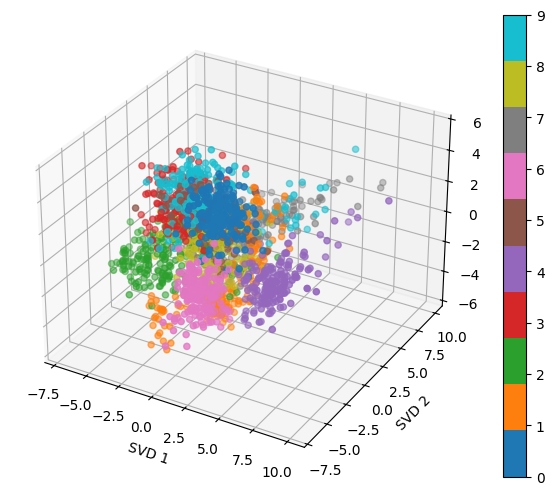

In [28]:
# 3D Scatter Plot
from mpl_toolkits.mplot3d import Axes3D

k_sc3 = 3
Uk_sc3 = U[:, :k_sc3]
Sk_sc3 = np.diag(S[:k_sc3])

x_3d = Uk_sc3 @ Sk_sc3

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(x_3d[:,0], x_3d[:,1], x_3d[:,2],
               c=y, cmap='tab10')
ax.set_xlabel("SVD 1")
ax.set_ylabel("SVD 2")

fig.colorbar(p)

Text(0.5, 0.98, 'Eigen-Digit (SVD Basis Image)')

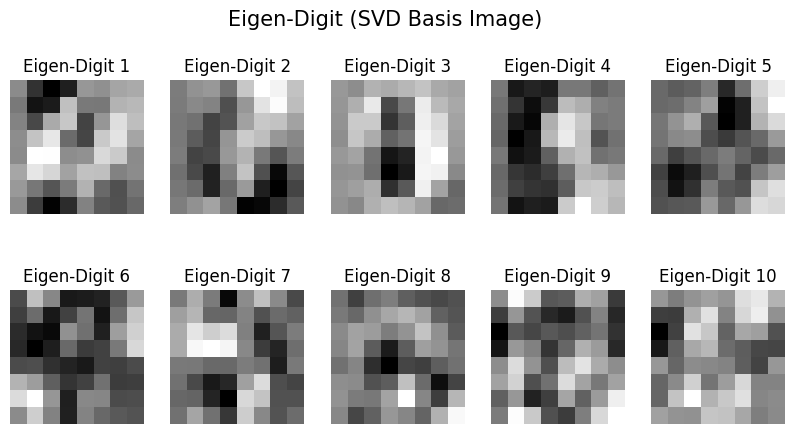

In [36]:
# visualize eigen-digits
num_eigen = 10 # show first 10 basis image

plt.figure(figsize=(10,5))
for i in range(num_eigen):
    plt.subplot(2, 5, i+1)
    eigendigit = Vt[i].reshape(8, 8)
    plt.imshow(eigendigit, cmap='gray')
    plt.title(f'Eigen-Digit {i+1}')
    plt.axis('off')

plt.suptitle('Eigen-Digit (SVD Basis Image)', fontsize=15)

## BEFORE & AFTER SVD

Original Image Shape      : (8, 8)
Reconstructed Image Shape : (8, 8)


(np.float64(-0.5), np.float64(7.5), np.float64(7.5), np.float64(-0.5))

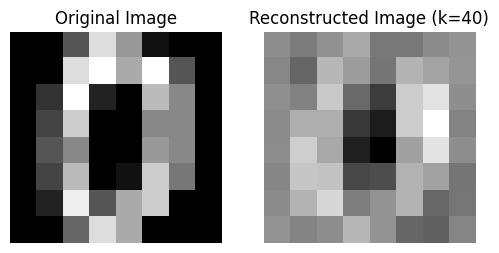

In [45]:
im_ind = 0

og_img = digits.images[im_ind]

print("Original Image Shape      :", og_img.shape)

ind = 0
rec = (Uk[ind] @ Sk @ Vtk).reshape(8,8)
print("Reconstructed Image Shape :", rec.shape)

plt.figure(figsize=(6,3))
plt.subplot(1, 2, 1)
plt.imshow(og_img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(rec, cmap='gray')
plt.title('Reconstructed Image (k=40)')
plt.axis('off')

# plt.title("BEFORE VS AFTER SVD")

## Train-Test-Split

In [48]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y,
                                                    test_size=0.3,
                                                    random_state=67)

CLF = LogisticRegression(max_iter=5000, multi_class='ovr')
CLF.fit(x_train, y_train)
y_pred = CLF.predict(x_test)

acc = accuracy_score(y_test, y_pred)

print(f"Accuracy without SVD = {acc:.4f}")

Accuracy without SVD = 0.9630


c:\Users\Shruti\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
